**Importing Necessary Dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Data Collection & Loading**

In [2]:
# load the dataset into a pandas DataFrame
df = pd.read_csv("../dataset/clean dataset/initial_telco_customer_churn_cleaned_dataset.csv")

In [3]:
# display first 5 rows of the dataset
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paper_less_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **2. Data Verification**

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         7043 non-null   object 
 1   gender              7043 non-null   object 
 2   senior_citizen      7043 non-null   int64  
 3   partner             7043 non-null   object 
 4   dependents          7043 non-null   object 
 5   tenure              7043 non-null   int64  
 6   phone_service       7043 non-null   object 
 7   multiple_lines      7043 non-null   object 
 8   internet_service    7043 non-null   object 
 9   online_security     7043 non-null   object 
 10  online_backup       7043 non-null   object 
 11  device_protection   7043 non-null   object 
 12  tech_support        7043 non-null   object 
 13  streaming_tv        7043 non-null   object 
 14  streaming_movies    7043 non-null   object 
 15  contract            7043 non-null   object 
 16  paper_

In [6]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paper_less_billing    0
payment_method        0
monthly_charges       0
total_charges         0
churn                 0
dtype: int64

In [9]:
# drop customer_id column as this is not required for modelling
df = df.drop(columns= ['customer_id'])

In [10]:
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paper_less_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **3. Exploratory Data Analysis (EDA)**

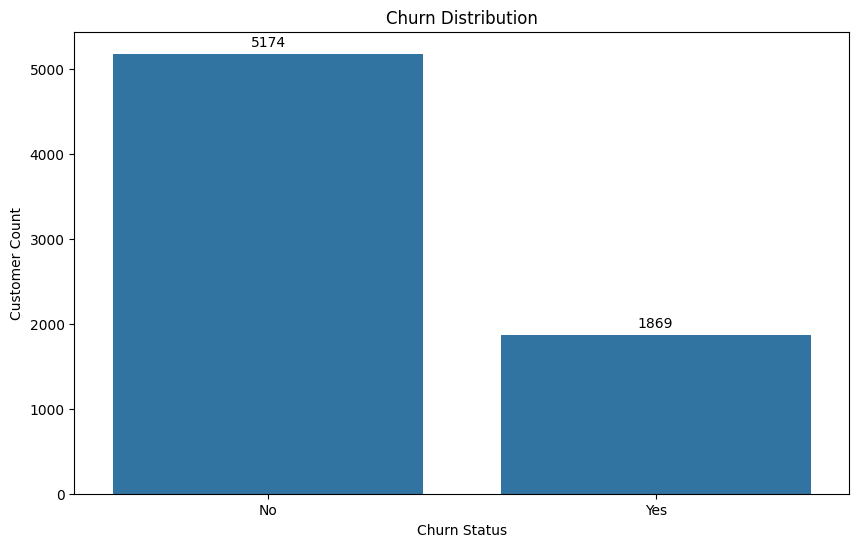

In [11]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="churn", data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")
plt.show()

In [12]:
print("Churn Rate Distribution:")
print(df['churn'].value_counts(normalize=True) * 100)

Churn Rate Distribution:
churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


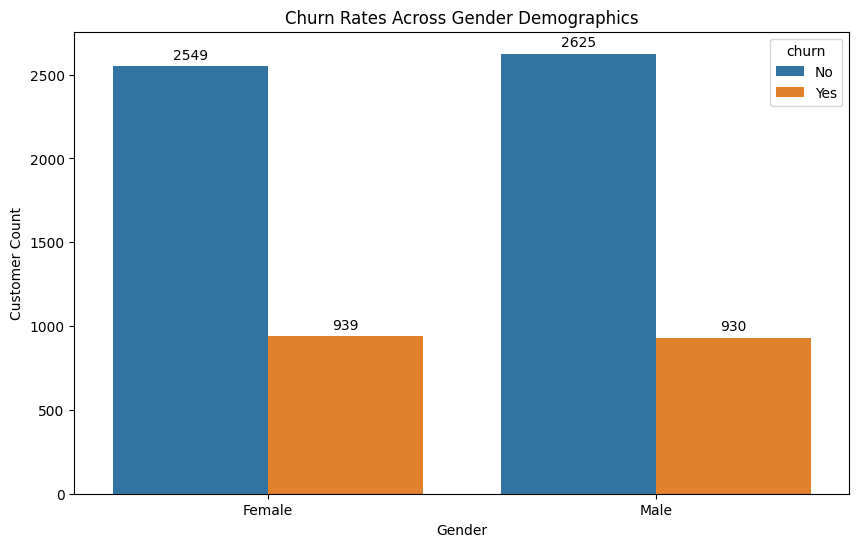

In [13]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="gender", hue='churn', data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Rates Across Gender Demographics")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

In [14]:
print("Churn Rate Distribution By Gender:")
print(df.groupby('gender')['churn'].value_counts(normalize=True) * 100)

Churn Rate Distribution By Gender:
gender  churn
Female  No       73.079128
        Yes      26.920872
Male    No       73.839662
        Yes      26.160338
Name: proportion, dtype: float64


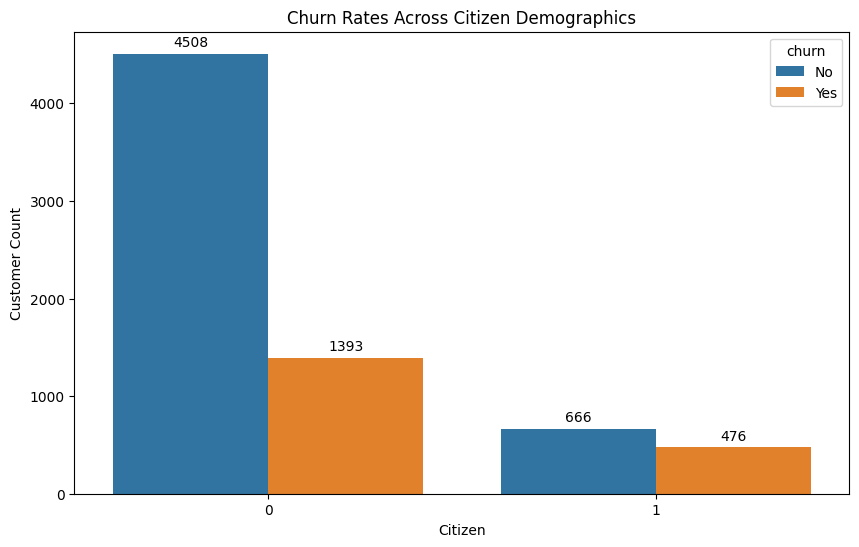

In [15]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="senior_citizen", hue='churn', data=df)

# Add label counts on top of the bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge",padding=3)

plt.title("Churn Rates Across Citizen Demographics")
plt.xlabel("Citizen")
plt.ylabel("Customer Count")
plt.show()

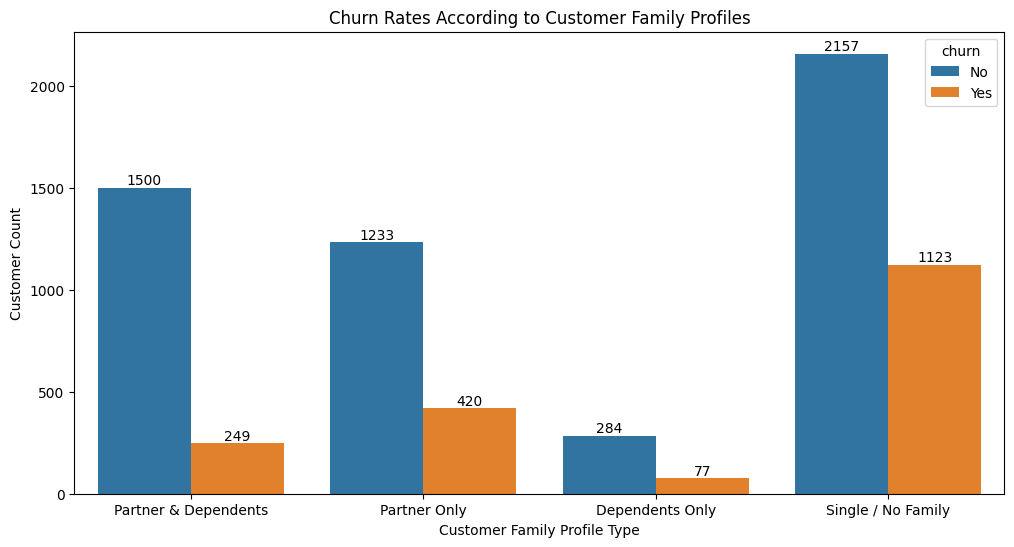

In [16]:
def get_customer_profile(row):
    if row['partner'] == 'Yes' and row['dependents'] == 'Yes':
        return 'Partner & Dependents'
    
    elif row['partner'] == 'Yes' and row['dependents'] == 'No':
        return 'Partner Only'
    
    elif row['partner'] == 'No' and row['dependents'] == 'Yes':
        return 'Dependents Only'
    
    else:
        return 'Single / No Family'

df['customer_profile'] = df.apply(get_customer_profile, axis=1)

plt.figure(figsize=(12,6))
ax= sns.countplot(x='customer_profile', hue='churn', data=df, order = ['Partner & Dependents', 'Partner Only', 'Dependents Only', 'Single / No Family'])

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Churn Rates According to Customer Family Profiles")
plt.xlabel("Customer Family Profile Type")
plt.ylabel("Customer Count")
plt.show()

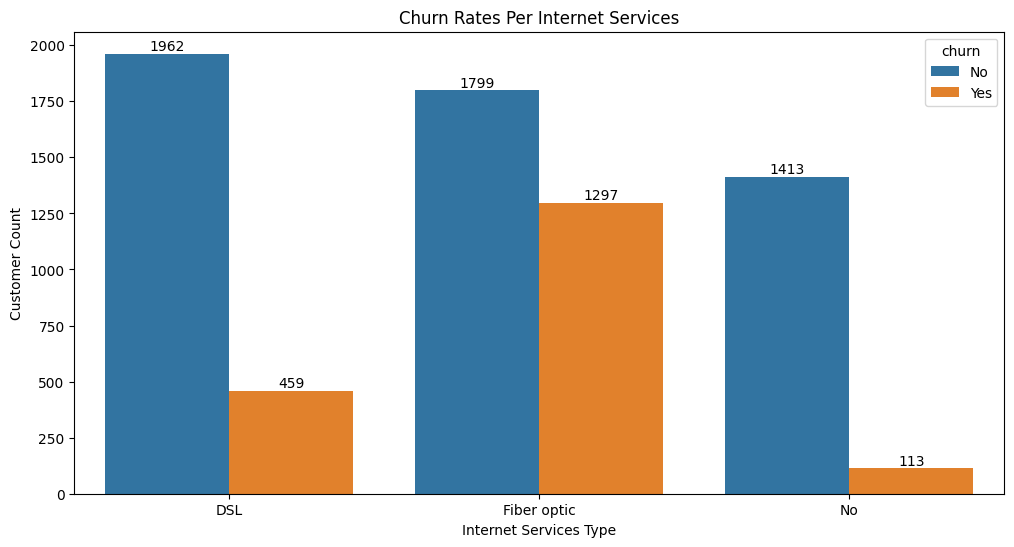

In [17]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="internet_service", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Churn Rates Per Internet Services")
plt.xlabel("Internet Services Type")
plt.ylabel("Customer Count")
plt.show()

In [18]:
print("Churn Rate Distribution By Internet Service:")
print(df.groupby('internet_service')['churn'].value_counts(normalize=True) * 100)

Churn Rate Distribution By Internet Service:
internet_service  churn
DSL               No       81.040892
                  Yes      18.959108
Fiber optic       No       58.107235
                  Yes      41.892765
No                No       92.595020
                  Yes       7.404980
Name: proportion, dtype: float64


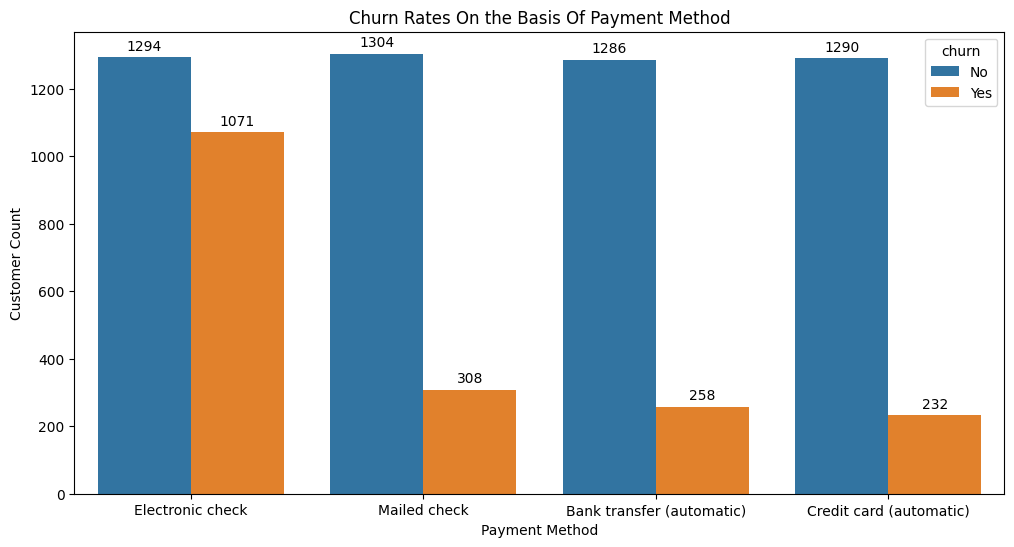

In [19]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="payment_method", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Churn Rates On the Basis Of Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.show()

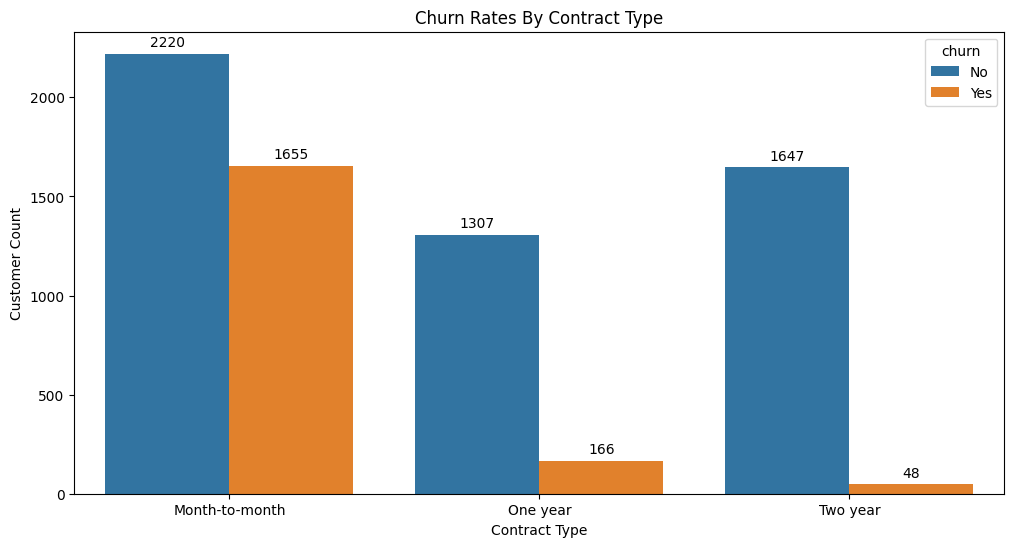

In [20]:
plt.figure(figsize=(12.,6))
ax=sns.countplot(data=df, x="contract", hue = "churn")

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Churn Rates By Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()

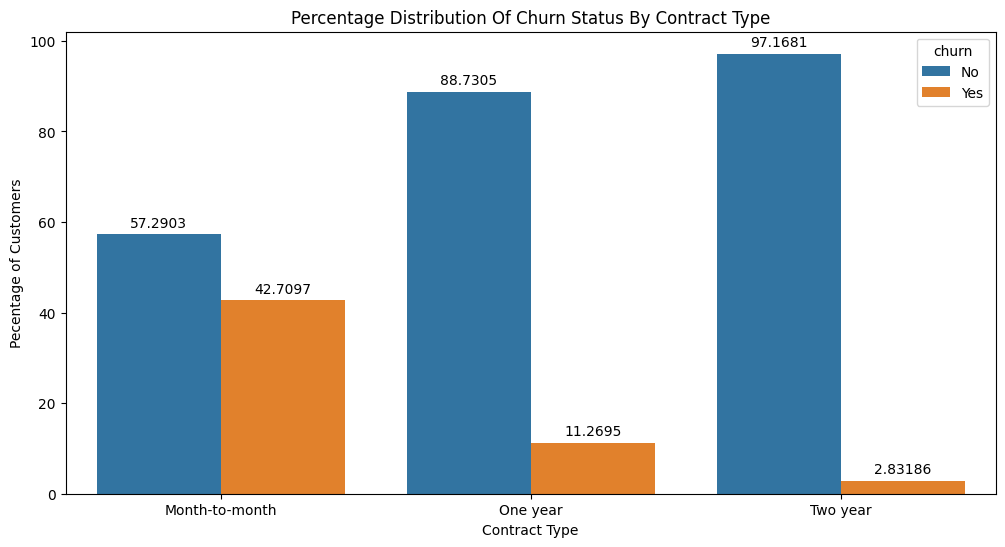

In [21]:
contract_churn =  df.groupby('contract')['churn'].value_counts(normalize=True).rename('churn_percentage').reset_index()
contract_churn['churn_percentage'] = contract_churn['churn_percentage'] * 100

plt.figure(figsize=(12.,6))
ax=sns.barplot(data= contract_churn, x="contract", y='churn_percentage', hue='churn', order = ['Month-to-month', 'One year', 'Two year'])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding = 3)

plt.title("Percentage Distribution Of Churn Status By Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Pecentage of Customers")
plt.show()

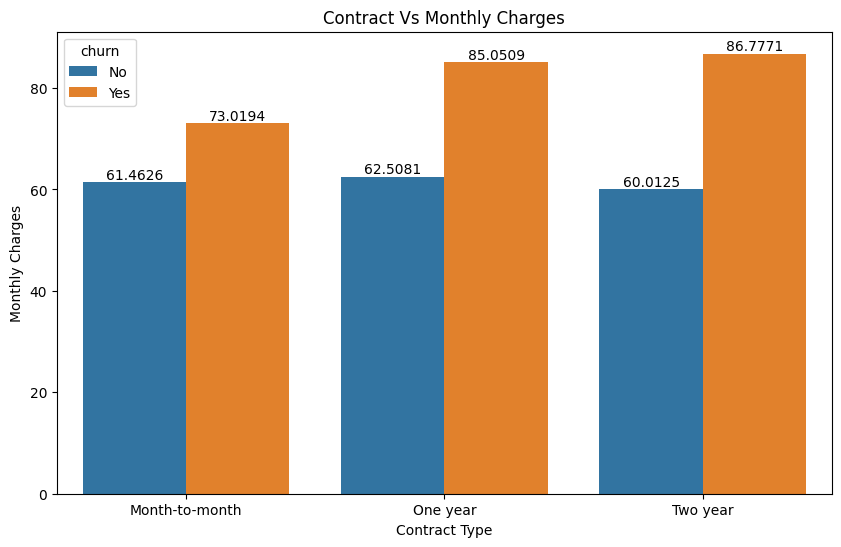

In [22]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x="contract", y="monthly_charges", hue="churn", data=df, errorbar = None)
 
for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Contract Vs Monthly Charges")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges")
plt.show()

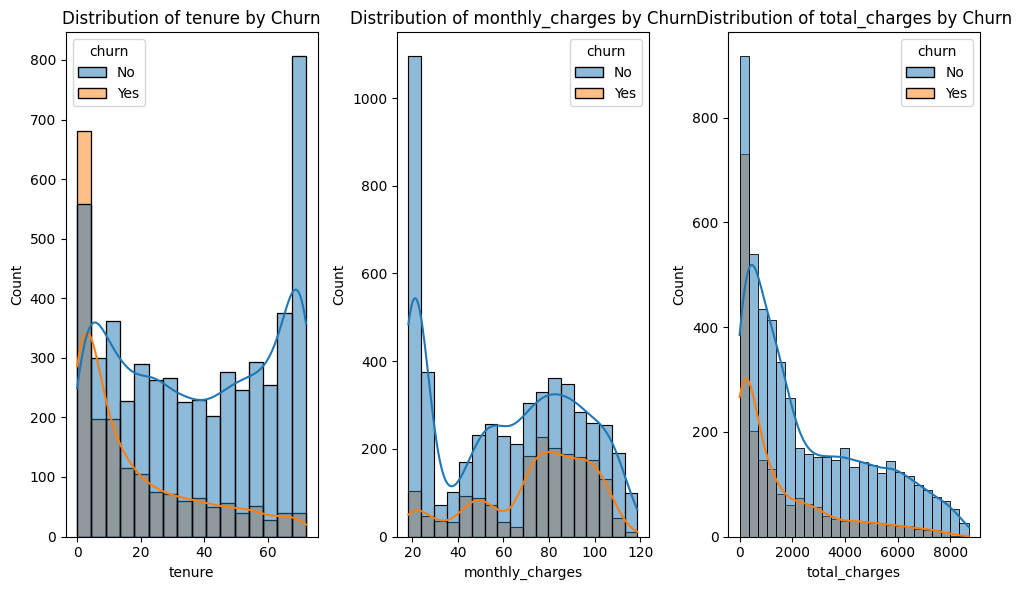

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(10,6))
numeric_cols = ['tenure', 'monthly_charges', 'total_charges']

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='churn', kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col} by Churn")

plt.tight_layout()
plt.show()

In [24]:
print("Average monthly charges by churn status:")
print(df.groupby('churn')['monthly_charges'].mean())
print("\n")
print("Average total charges by churn status:")
print(df.groupby('churn')['total_charges'].mean())

Average monthly charges by churn status:
churn
No     61.265124
Yes    74.441332
Name: monthly_charges, dtype: float64


Average total charges by churn status:
churn
No     2549.911442
Yes    1531.796094
Name: total_charges, dtype: float64


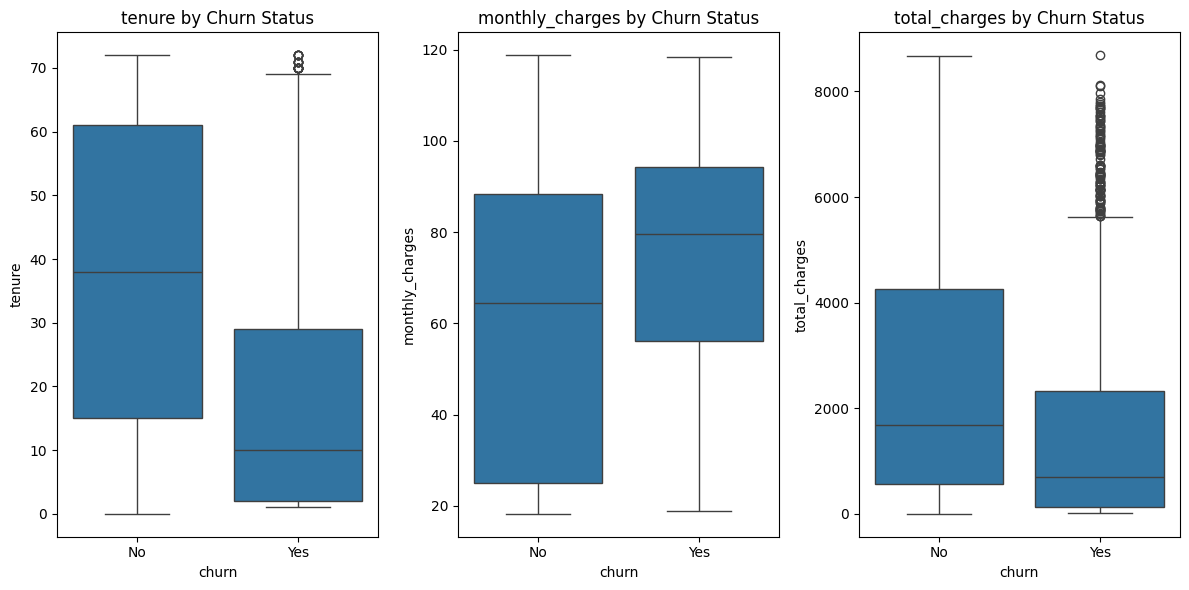

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12,6))
numeric_cols = ['tenure', 'monthly_charges', 'total_charges']

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='churn', y=col,  ax=axes[i])
    axes[i].set_title(f"{col} by Churn Status")

plt.tight_layout()
plt.show()

In [26]:
# Group the tenure columns into a group
df['tenure_groups'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels = ["0-1 Year", "1-2 Years", "2-4 Years", "4+ Years"])

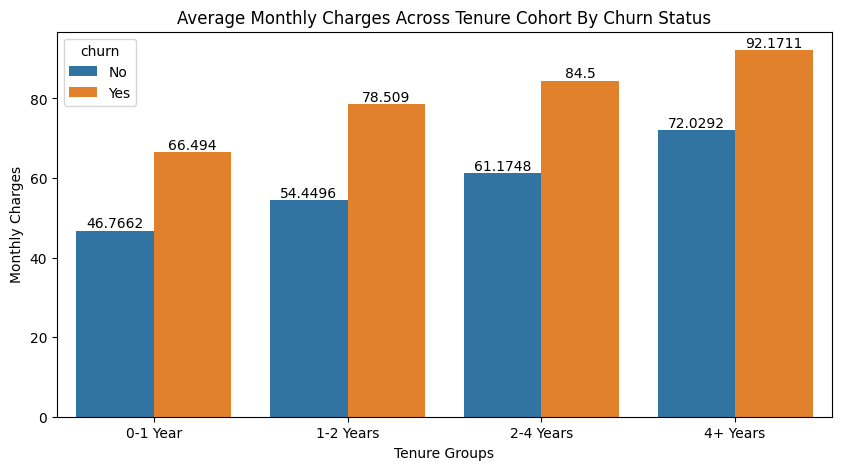

In [27]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x="tenure_groups", y="monthly_charges", hue='churn', data=df, errorbar=None)

for container in ax.containers:
    ax.bar_label(container, label_type='edge')

plt.title("Average Monthly Charges Across Tenure Cohort By Churn Status")
plt.xlabel("Tenure Groups")
plt.ylabel("Monthly Charges")
plt.show()

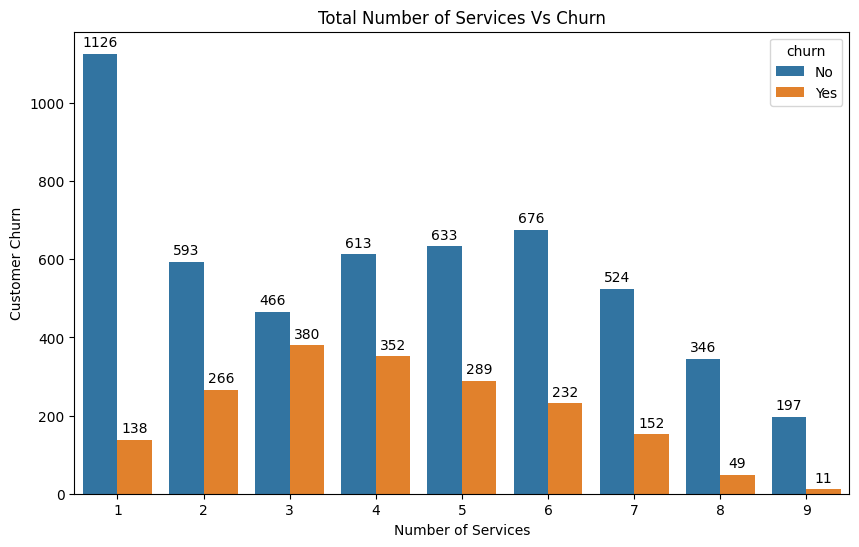

In [28]:
# create a services list
services_cols = ['phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']

df['total_services'] = (
    (df['phone_service'] == 'Yes').astype(int) + 
    (df['multiple_lines'] == 'Yes').astype(int) + 
    (df['internet_service'] != 'No').astype(int) + 
    (df['online_security'] == 'Yes').astype(int) + 
    (df['online_backup'] == 'Yes').astype(int) + 
    (df['device_protection'] == 'Yes').astype(int) + 
    (df['tech_support'] == 'Yes').astype(int) + 
    (df['streaming_tv'] == 'Yes').astype(int) + 
    (df['streaming_movies'] == 'Yes').astype(int)
)

plt.figure(figsize = (10,6))
ax = sns.countplot(x='total_services', hue='churn', data=df)
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title("Total Number of Services Vs Churn")
plt.xlabel("Number of Services")
plt.ylabel("Customer Churn")
plt.show()

In [29]:
# Convert 'churn' into a numerical value (0 and 1) so the correlation matrix can read it
df['churn_numeric'] = df['churn'].map({'Yes': 1, 'No':0})

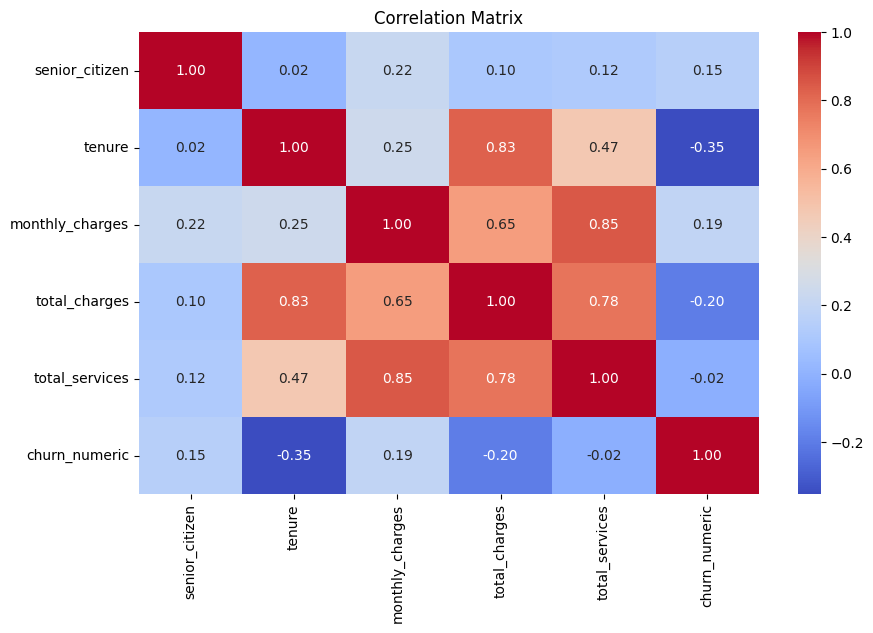

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot = True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

To check for the correlation relationship between all the numerical features, I plotted correlation matrix. I noticed that total_charges and tenure are highly correlated which means before training machine learning model I need to handle this redundancy. 

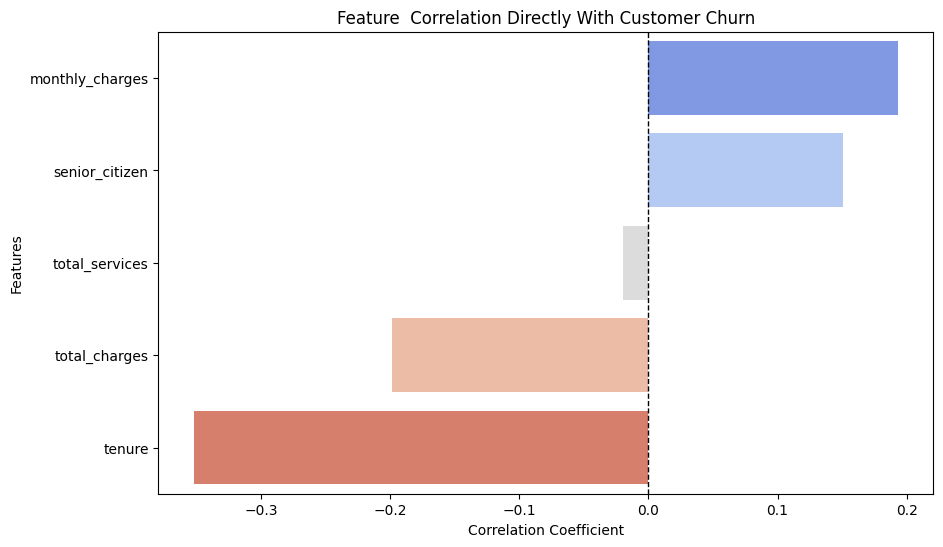

In [31]:
plt.figure(figsize=(10,6))

# Isolate just the correlations relative to churn and sort them 
churn_corr = df.select_dtypes(include=['number']).corr()['churn_numeric'].sort_values(ascending=False)

# Drop the churn column itself so it doesn't correlate with itself
churn_corr = churn_corr.drop('churn_numeric')

# Add a center line
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
sns.barplot(x=churn_corr.values, y=churn_corr.index, hue=churn_corr.index, palette = 'coolwarm', legend=False)
plt.title("Feature  Correlation Directly With Customer Churn")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show() 

To understand how features correlate and impact customer turnover, I plotted a barplot which shows only correlations directly related to churn status. The barplot clearly demonstrates that monthly charges mostly causes customer churn, while tenure is the opposite, which shows the longer the tenure the less the customer churn .

 ## **4. Key Findings**

- **Churn Status Overview:** Around 26.5% of customers churned while about 73.46 % of customer were retained.

- **Churn Status According to Gender:** Both male and female customers had similar churn percentage of around 26%, suggesting that gender demographics doesn't really affect the churn behavior.

- **Churn Status Per Internet Service:** Customers were more likely to churn, when they had Fiber optic as their internet service. Where as customer who have had DSL as their internet service were more likely to stay compared to Fiber optic. This suggests potential issues with fiber optic pricing or service quality that needs to be studied.

- **Churn Status According to The Payment Method:** From the four payment method, customers paying using Electronic Check had the highest churn rate while Credit Card (automatic) method had the lowest churn rate.

- **Churn Status By Contract Type:** Mont6h-to-month contract customers churned the most while customers on one or two year contracts were significantly more loyal, suggesting longer contracts strongly reduce churn risk.

- **Churn Stats By Tenure:** Customers with short tenure years churned more frequently than customers who have a long tenure years.

- **Churn Status by Monthly and Total Renue Charges:** Churned customers paid higher average monthly charges than retained customers, suggesting that high pricing most likely causes churning

- **Senior Citizens:** Senior citizen customers showed high churn rates compared to non-senior customers

- **Services:** Customers subscribed to multiple services churned less frequently, suggesting that the more the customers have additonal services, the less the risk of churn 

## **5. Export the Dataset**

In [32]:
# export and save dataset
df.to_csv("../dataset/clean dataset/final_telco_customer_churn_cleaned_dataset.csv", index=False)